In [1]:
!pip install GEOparse pandas numpy scipy matplotlib seaborn scikit-learn gseapy statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 3.7 MB/s eta 0:00:00


In [2]:
import GEOparse

gse = GEOparse.get_GEO("GSE62598", destdir=".")

24-Apr-2026 12:41:14 DEBUG utils - Directory . already exists. Skipping.
DEBUG:GEOparse:Directory . already exists. Skipping.
24-Apr-2026 12:41:14 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE62nnn/GSE62598/soft/GSE62598_family.soft.gz to ./GSE62598_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE62nnn/GSE62598/soft/GSE62598_family.soft.gz to ./GSE62598_family.soft.gz
100%|██████████| 12.1M/12.1M [00:03<00:00, 4.07MB/s]
24-Apr-2026 12:41:18 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
24-Apr-2026 12:41:18 DEBUG downloader - Moving /tmp/tmp4s0m7jd9 to /content/GSE62598_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp4s0m7jd9 to /content/GSE62598_family.soft.gz
24-Apr-2026 12:41:18 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE62nnn/GSE62598/soft/GSE62598_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE62nnn/GSE6259

In [3]:
print(gse)
print("Number of samples:", len(gse.gsms))

<SERIES: GSE62598 - 15 SAMPLES, 1 d(s)>
Number of samples: 15


In [4]:
for gsm_name, gsm in gse.gsms.items():
    print(gsm_name, "->", gsm.metadata.get("title", [""])[0])

GSM1529765 -> 4T1 parental rep D
GSM1529766 -> 4T1 parental rep E
GSM1529767 -> 4T1 parental rep F
GSM1529768 -> 148 primary tumor explant
GSM1529769 -> 152 primary tumor explant
GSM1529770 -> 154 primary tumor explant
GSM1529771 -> 526 lung-aggressive explant
GSM1529772 -> 533 lung-aggressive explant
GSM1529773 -> 537 lung-aggressive explant
GSM1529774 -> 590 bone-aggressive explant
GSM1529775 -> 592 bone-aggressive explant
GSM1529776 -> 593 bone-aggressive explant
GSM1529777 -> 2776 liver-aggressive explant
GSM1529778 -> 2792 liver-aggressive explant
GSM1529779 -> 2869 liver-aggressive explant


In [5]:
import pandas as pd

sample_info = []

for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata.get("title", [""])[0]

    if "parental" in title.lower():
        group = "parental"
    elif "primary" in title.lower():
        group = "primary"
    elif "lung-aggressive" in title.lower():
        group = "lung"
    elif "bone-aggressive" in title.lower():
        group = "bone"
    elif "liver-aggressive" in title.lower():
        group = "liver"
    else:
        group = "unknown"

    sample_info.append({
        "sample_id": gsm_name,
        "title": title,
        "group": group
    })

metadata_df = pd.DataFrame(sample_info)
metadata_df

,sample_id,title,group
0,GSM1529765,4T1 parental rep D,parental
1,GSM1529766,4T1 parental rep E,parental
2,GSM1529767,4T1 parental rep F,parental
3,GSM1529768,148 primary tumor explant,primary
4,GSM1529769,152 primary tumor explant,primary
5,GSM1529770,154 primary tumor explant,primary
6,GSM1529771,526 lung-aggressive explant,lung
7,GSM1529772,533 lung-aggressive explant,lung
8,GSM1529773,537 lung-aggressive explant,lung
9,GSM1529774,590 bone-aggressive explant,bone


In [6]:
metadata_df["group"].value_counts()

,count
group,
parental,3
primary,3
lung,3
bone,3
liver,3


In [7]:
expression_dfs = []

for gsm_name, gsm in gse.gsms.items():
    df = gsm.table.copy()

    # Print columns once to inspect structure
    print(gsm_name, df.columns.tolist()[:10])
    break

GSM1529765 ['ID_REF', 'VALUE']


In [9]:
expression_dfs = []

for gsm_name, gsm in gse.gsms.items():
    df = gsm.table.copy()

    # Usually the expression column is called "VALUE"
    temp = df[["ID_REF", "VALUE"]].copy()
    temp.columns = ["probe_id", gsm_name]
    expression_dfs.append(temp)

# Merge all samples by probe_id
expr_df = expression_dfs[0]
for temp in expression_dfs[1:]:
    expr_df = expr_df.merge(temp, on="probe_id", how="inner")

expr_df.head()

,probe_id,GSM1529765,GSM1529766,GSM1529767,GSM1529768,GSM1529769,GSM1529770,GSM1529771,GSM1529772,GSM1529773,GSM1529774,GSM1529775,GSM1529776,GSM1529777,GSM1529778,GSM1529779
0,A_52_P616356,0.861248,1.363152,1.474852,1.163851,1.182875,0.534334,0.789739,1.000000,0.601383,1.339290,1.218378,1.424259,0.972839,0.252193,0.642165
1,A_52_P580582,0.989682,1.242424,1.266278,1.019961,0.967356,1.193899,0.808226,1.000000,1.054647,1.134424,0.886047,0.802322,0.811757,1.338101,0.841438
2,A_52_P403405,0.773578,0.869576,1.644678,1.025332,1.495560,0.481866,1.000000,1.183150,0.722128,0.853336,1.548389,2.079587,2.394513,0.282306,0.866977
3,A_52_P819156,1.038099,0.614743,0.908562,0.744383,1.070034,1.000000,0.715116,2.258637,4.998555,0.613183,1.124689,0.961456,8.107326,0.560833,2.602255
4,A_51_P331831,1.195069,0.961940,0.892502,1.135993,1.008034,0.856920,0.785707,1.066812,1.040365,0.764020,0.908937,1.421265,3.672986,1.000000,0.701686


In [10]:
expr_df.shape

(41265, 16)

In [11]:
# Set probe IDs as index
expr_df = expr_df.set_index("probe_id")

# Convert everything to numeric
expr_df = expr_df.apply(pd.to_numeric, errors="coerce")

# Check missing values
print(expr_df.isna().sum().sum())

0


In [12]:
metadata_df = metadata_df.set_index("sample_id")
metadata_df = metadata_df.loc[expr_df.columns]
metadata_df.head()

,title,group
GSM1529765,4T1 parental rep D,parental
GSM1529766,4T1 parental rep E,parental
GSM1529767,4T1 parental rep F,parental
GSM1529768,148 primary tumor explant,primary
GSM1529769,152 primary tumor explant,primary


In [13]:
print(expr_df.iloc[:5, :5])
print(metadata_df["group"])

              GSM1529765  GSM1529766  GSM1529767  GSM1529768  GSM1529769
probe_id                                                                
A_52_P616356    0.861248    1.363152    1.474852    1.163851    1.182875
A_52_P580582    0.989682    1.242424    1.266278    1.019961    0.967356
A_52_P403405    0.773578    0.869576    1.644678    1.025332    1.495560
A_52_P819156    1.038099    0.614743    0.908562    0.744383    1.070034
A_51_P331831    1.195069    0.961940    0.892502    1.135993    1.008034
GSM1529765    parental
GSM1529766    parental
GSM1529767    parental
GSM1529768     primary
GSM1529769     primary
GSM1529770     primary
GSM1529771        lung
GSM1529772        lung
GSM1529773        lung
GSM1529774        bone
GSM1529775        bone
GSM1529776        bone
GSM1529777       liver
GSM1529778       liver
GSM1529779       liver
Name: group, dtype: object


In [14]:
expr_df.to_csv("GSE62598_expression_matrix.csv")
metadata_df.to_csv("GSE62598_metadata.csv")

In [15]:
print(expr_df.shape)
print(metadata_df["group"].value_counts())

(41265, 15)
group
parental    3
primary     3
lung        3
bone        3
liver       3
Name: count, dtype: int64


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Transpose: samples as rows
X = expr_df.T

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [19]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["group"] = metadata_df["group"].values
pca_df.index = X.index  # sample IDs

pca_df.head()

,PC1,PC2,group
GSM1529765,-15.941278,100.932964,parental
GSM1529766,58.685022,91.068498,parental
GSM1529767,118.845506,106.426505,parental
GSM1529768,17.329235,-15.503584,primary
GSM1529769,32.944769,8.156213,primary


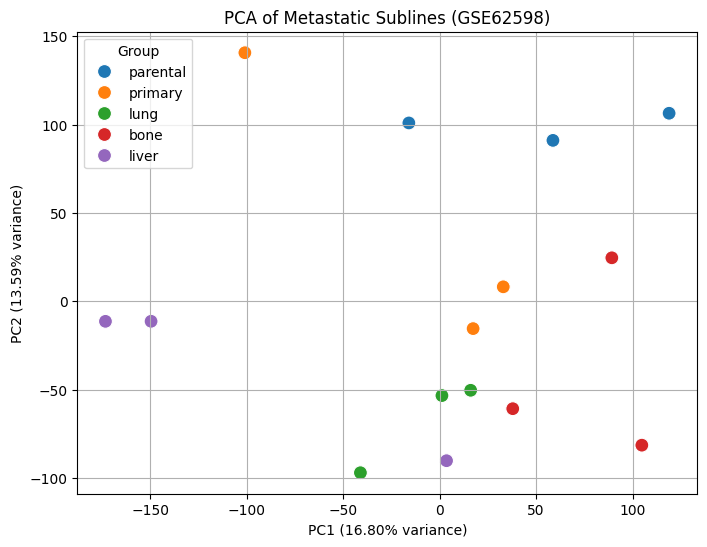

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    s=100
)

plt.title("PCA of Metastatic Sublines (GSE62598)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.legend(title="Group")
plt.grid()

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


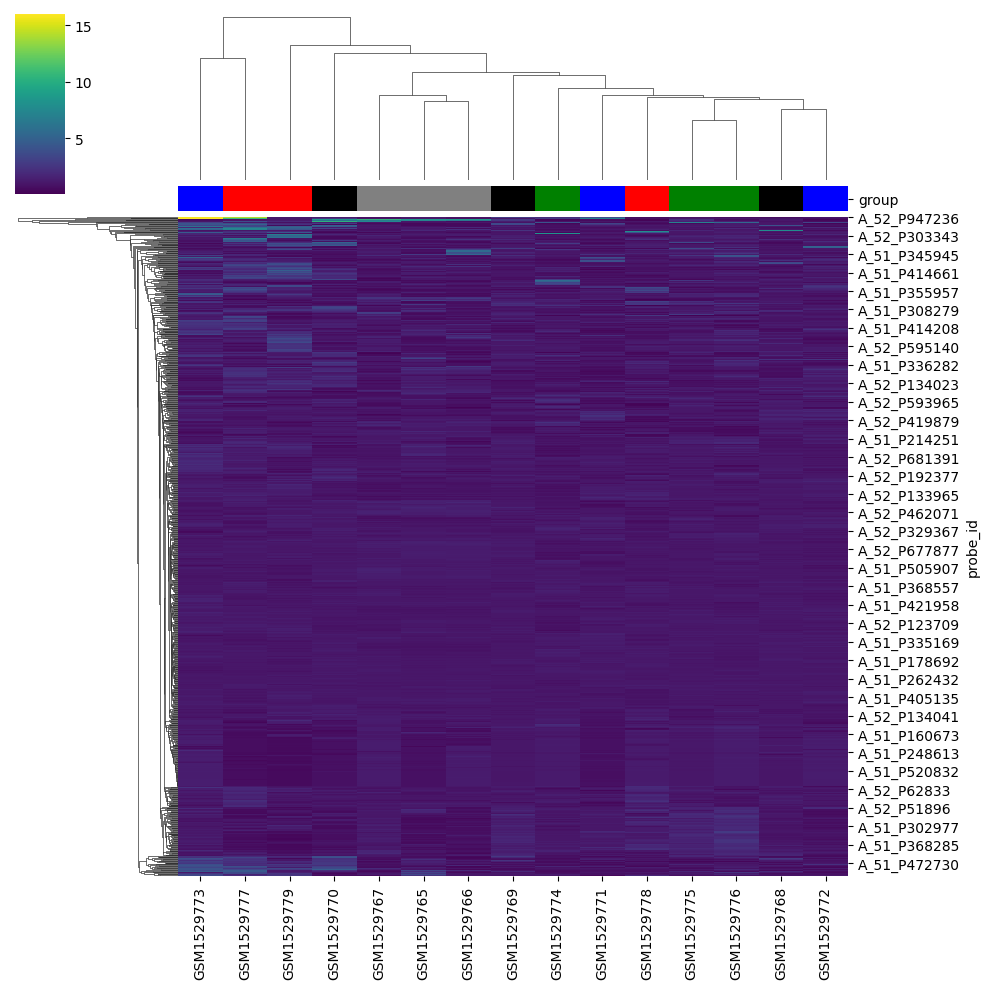

In [21]:
sns.clustermap(
    expr_df.iloc[:1000],  # subset to avoid overload
    cmap="viridis",
    col_colors=metadata_df["group"].map({
        "parental": "gray",
        "primary": "black",
        "lung": "blue",
        "bone": "green",
        "liver": "red"
    }),
    figsize=(10,10)
)

In [22]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

def differential_expression(group1, group2):
    samples1 = metadata_df[metadata_df["group"] == group1].index
    samples2 = metadata_df[metadata_df["group"] == group2].index

    results = []

    for gene in expr_df.index:
        vals1 = expr_df.loc[gene, samples1]
        vals2 = expr_df.loc[gene, samples2]

        stat, pval = ttest_ind(vals1, vals2, equal_var=False)
        log2fc = np.log2(vals1.mean() + 1e-6) - np.log2(vals2.mean() + 1e-6)

        results.append([gene, log2fc, pval])

    res_df = pd.DataFrame(results, columns=["gene", "log2FC", "pval"])

    # Adjust p-values (FDR)
    from statsmodels.stats.multitest import multipletests
    res_df["FDR"] = multipletests(res_df["pval"], method='fdr_bh')[1]

    return res_df.sort_values("FDR")

In [23]:
liver_vs_lung = differential_expression("liver", "lung")
liver_vs_bone = differential_expression("liver", "bone")

In [24]:
sig_liver_lung = liver_vs_lung[
    (liver_vs_lung["FDR"] < 0.05) &
    (abs(liver_vs_lung["log2FC"]) > 1)
]

sig_liver_bone = liver_vs_bone[
    (liver_vs_bone["FDR"] < 0.05) &
    (abs(liver_vs_bone["log2FC"]) > 1)
]

print(len(sig_liver_lung), "significant genes (liver vs lung)")
print(len(sig_liver_bone), "significant genes (liver vs bone)")

0 significant genes (liver vs lung)
0 significant genes (liver vs bone)


In [25]:
sig_liver_lung = liver_vs_lung[
    (liver_vs_lung["pval"] < 0.05) &
    (abs(liver_vs_lung["log2FC"]) > 0.5)
]

sig_liver_bone = liver_vs_bone[
    (liver_vs_bone["pval"] < 0.05) &
    (abs(liver_vs_bone["log2FC"]) > 0.5)
]

print(len(sig_liver_lung))
print(len(sig_liver_bone))

796
1504


In [26]:
ranked_liver_lung = liver_vs_lung[["gene", "log2FC"]]
ranked_liver_lung = ranked_liver_lung.sort_values("log2FC", ascending=False)

ranked_liver_bone = liver_vs_bone[["gene", "log2FC"]]
ranked_liver_bone = ranked_liver_bone.sort_values("log2FC", ascending=False)

In [29]:
import gseapy as gp

libs = gp.get_library_name()
print(libs[:20])

['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020']


In [30]:
ranked_liver_lung.head()

,gene,log2FC
24324,A_52_P716032,6.782106
23373,A_51_P190639,6.093544
23837,A_52_P371971,5.982868
24078,A_52_P369996,5.875084
23292,A_52_P423296,5.750181


In [31]:
for gsm_name, gsm in gse.gsms.items():
    print(gsm.table.columns)
    break

Index(['ID_REF', 'VALUE'], dtype='object')


In [34]:
print(gse.gpls.keys())

dict_keys(['GPL7202'])


In [35]:
gpl = list(gse.gpls.values())[0]
print(gpl)

<d: GPL7202>


In [36]:
gpl_table = gpl.table
print(gpl_table.columns)

Index(['ID', 'SPOT_ID', 'CONTROL_TYPE', 'REFSEQ', 'GB_ACC', 'GENE',
       'GENE_SYMBOL', 'GENE_NAME', 'UNIGENE_ID', 'ENSEMBL_ID', 'TIGR_ID',
       'ACCESSION_STRING', 'CHROMOSOMAL_LOCATION', 'CYTOBAND', 'DESCRIPTION',
       'GO_ID', 'SEQUENCE'],
      dtype='object')


In [37]:
probe_to_gene = gpl_table[["ID", "GENE_SYMBOL"]].copy()
probe_to_gene.columns = ["probe_id", "gene"]

# Remove missing or empty gene names
probe_to_gene = probe_to_gene.dropna()
probe_to_gene = probe_to_gene[probe_to_gene["gene"] != ""]

In [38]:
probe_to_gene["gene"] = probe_to_gene["gene"].str.split("///").str[0]
probe_to_gene["gene"] = probe_to_gene["gene"].str.strip()

In [39]:
expr_df = expr_df.reset_index()  # bring probe_id into a column

expr_df = expr_df.merge(probe_to_gene, on="probe_id")

expr_df.head()

,probe_id,GSM1529765,GSM1529766,GSM1529767,GSM1529768,GSM1529769,GSM1529770,GSM1529771,GSM1529772,GSM1529773,GSM1529774,GSM1529775,GSM1529776,GSM1529777,GSM1529778,GSM1529779,gene
0,A_52_P616356,0.861248,1.363152,1.474852,1.163851,1.182875,0.534334,0.789739,1.000000,0.601383,1.339290,1.218378,1.424259,0.972839,0.252193,0.642165,Ccr1
1,A_52_P580582,0.989682,1.242424,1.266278,1.019961,0.967356,1.193899,0.808226,1.000000,1.054647,1.134424,0.886047,0.802322,0.811757,1.338101,0.841438,Nppa
2,A_52_P403405,0.773578,0.869576,1.644678,1.025332,1.495560,0.481866,1.000000,1.183150,0.722128,0.853336,1.548389,2.079587,2.394513,0.282306,0.866977,Aqp7
3,A_51_P331831,1.195069,0.961940,0.892502,1.135993,1.008034,0.856920,0.785707,1.066812,1.040365,0.764020,0.908937,1.421265,3.672986,1.000000,0.701686,Hvcn1
4,A_51_P430630,0.868203,0.588984,1.292107,1.267315,1.386741,1.000000,0.929156,0.933906,1.119784,0.704473,1.446991,0.404931,4.782007,0.279070,1.631802,Gpr33


In [41]:
print(expr_df.columns)

Index(['probe_id', 'GSM1529765', 'GSM1529766', 'GSM1529767', 'GSM1529768',
       'GSM1529769', 'GSM1529770', 'GSM1529771', 'GSM1529772', 'GSM1529773',
       'GSM1529774', 'GSM1529775', 'GSM1529776', 'GSM1529777', 'GSM1529778',
       'GSM1529779', 'gene'],
      dtype='object')


In [42]:
# Identify sample columns (everything except probe_id and gene)
sample_cols = [col for col in expr_df.columns if col not in ["probe_id", "gene"]]

# Keep only needed columns
expr_df_clean = expr_df[["gene"] + sample_cols]

In [43]:
expr_df_gene = expr_df_clean.groupby("gene").mean()

In [44]:
print(expr_df_gene.shape)
expr_df_gene.head()

(21200, 15)


,GSM1529765,GSM1529766,GSM1529767,GSM1529768,GSM1529769,GSM1529770,GSM1529771,GSM1529772,GSM1529773,GSM1529774,GSM1529775,GSM1529776,GSM1529777,GSM1529778,GSM1529779
gene,,,,,,,,,,,,,,,
0610005C13Rik,1.035773,0.877498,0.825273,0.945055,1.290487,0.851301,1.079424,0.817227,1.629367,0.709414,0.979876,1.125072,1.000000,1.105846,1.300755
0610007C21Rik,0.759389,0.793083,0.822925,1.062975,0.860147,0.865423,1.276812,1.000000,1.098767,1.087657,1.229396,0.778791,1.076055,1.007828,0.867346
0610007L01Rik,0.912488,0.944095,0.957675,0.966679,0.969106,1.008582,1.172977,0.962084,0.999873,1.025118,1.136578,1.031872,0.964261,0.990883,1.063484
0610007N19Rik,1.055498,1.051423,0.783672,1.045462,0.639133,1.628197,0.981680,1.089860,1.000000,0.971032,0.872171,0.854021,2.144850,0.928830,1.113917
0610007P08Rik,1.583050,1.068239,0.787537,1.037023,0.959018,1.450363,1.162302,0.834865,1.040256,0.822503,1.281617,1.113544,1.033433,0.857903,1.131848


In [45]:
X = expr_df_gene.T

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

In [47]:
# Compute variance of each gene
gene_variance = expr_df_gene.var(axis=1)

# Select top 1000 most variable genes
top_genes = gene_variance.sort_values(ascending=False).head(1000).index

# Subset data
X = expr_df_gene.loc[top_genes].T

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [50]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["group"] = metadata_df["group"].values
pca_df.index = X.index

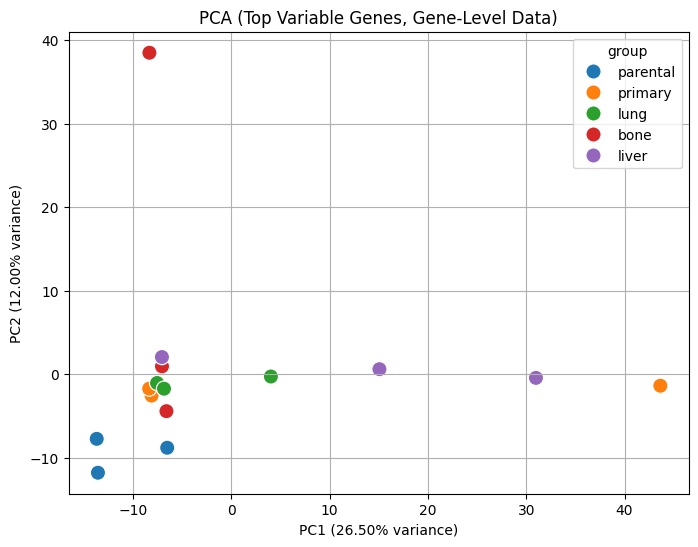

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="group",
    s=120
)

plt.title("PCA (Top Variable Genes, Gene-Level Data)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)")
plt.grid()

plt.show()

In [54]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def differential_expression(group1, group2, expr_df, metadata_df):
    samples1 = metadata_df[metadata_df["group"] == group1].index
    samples2 = metadata_df[metadata_df["group"] == group2].index

    results = []

    for gene in expr_df.index:
        vals1 = expr_df.loc[gene, samples1].astype(float)
        vals2 = expr_df.loc[gene, samples2].astype(float)

        # Skip genes with zero variance (important)
        if vals1.var() == 0 and vals2.var() == 0:
            continue

        stat, pval = ttest_ind(vals1, vals2, equal_var=False)

        # safer log2FC
        log2fc = np.log2(vals1.mean() + 1e-6) - np.log2(vals2.mean() + 1e-6)

        results.append([gene, log2fc, pval])

    res_df = pd.DataFrame(results, columns=["gene", "log2FC", "pval"])

    # FDR correction
    res_df["FDR"] = multipletests(res_df["pval"], method='fdr_bh')[1]

    return res_df.sort_values("FDR")

In [55]:
liver_vs_lung = differential_expression("liver", "lung", expr_df_gene, metadata_df)
liver_vs_bone = differential_expression("liver", "bone", expr_df_gene, metadata_df)

In [56]:
sig_liver_lung = liver_vs_lung[
    (liver_vs_lung["FDR"] < 0.05) &
    (abs(liver_vs_lung["log2FC"]) > 1)
]

sig_liver_bone = liver_vs_bone[
    (liver_vs_bone["FDR"] < 0.05) &
    (abs(liver_vs_bone["log2FC"]) > 1)
]

In [57]:
sig_liver_lung_relaxed = liver_vs_lung[
    (liver_vs_lung["pval"] < 0.05) &
    (abs(liver_vs_lung["log2FC"]) > 0.5)
]

sig_liver_bone_relaxed = liver_vs_bone[
    (liver_vs_bone["pval"] < 0.05) &
    (abs(liver_vs_bone["log2FC"]) > 0.5)
]

In [58]:
print("Strict thresholds:")
print("Liver vs Lung:", len(sig_liver_lung))
print("Liver vs Bone:", len(sig_liver_bone))

print("\nRelaxed thresholds:")
print("Liver vs Lung:", len(sig_liver_lung_relaxed))
print("Liver vs Bone:", len(sig_liver_bone_relaxed))

Strict thresholds:
Liver vs Lung: 0
Liver vs Bone: 0

Relaxed thresholds:
Liver vs Lung: 373
Liver vs Bone: 708


In [59]:
print("Top genes (Liver vs Lung):")
print(liver_vs_lung.head(10))

print("\nTop genes (Liver vs Bone):")
print(liver_vs_bone.head(10))

Top genes (Liver vs Lung):
          gene    log2FC      pval       FDR
16210    Reep2  0.770607  0.421526  0.871858
7526   Fam118a  0.167180  0.076392  0.871858
7522   Fam116a  0.173627  0.291922  0.871858
7520   Fam115a  0.861885  0.320569  0.871858
16223     Rela -0.129065  0.385755  0.871858
16221     Reg4  0.533761  0.259105  0.871858
16220    Reg3g -0.542286  0.300378  0.871858
16217    Reg3a  1.592403  0.155535  0.871858
16215     Reg1  1.508331  0.288680  0.871858
16213    Reep5 -0.853662  0.004478  0.871858

Top genes (Liver vs Bone):
         gene    log2FC          pval       FDR
4637   Ccdc34 -0.209528  4.487778e-07  0.009514
19001   Tmcc3 -1.139112  1.015728e-04  0.399145
14670  Pdik1l  0.513542  6.437875e-05  0.399145
16863    Scap -0.332310  1.013769e-04  0.399145
10966    Krt9  0.916731  1.129655e-04  0.399145
14601   Pcsk7 -0.435837  6.881104e-05  0.399145
8263   Galnt1 -1.085572  1.789670e-04  0.430853
17748   Smad4 -0.590216  1.579215e-04  0.430853
6329    Dctn4 -0.4

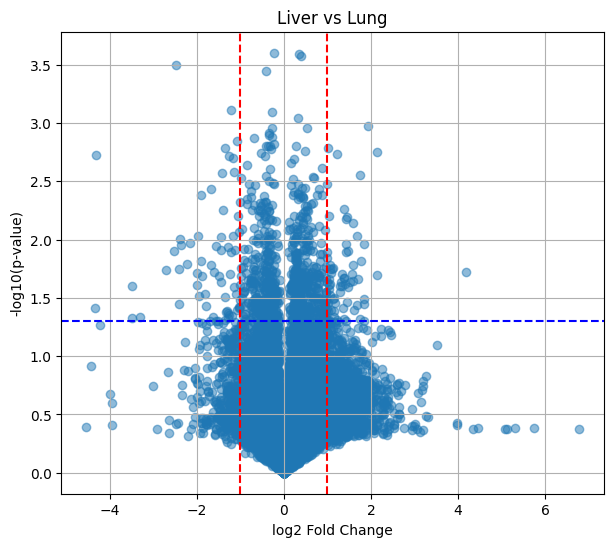

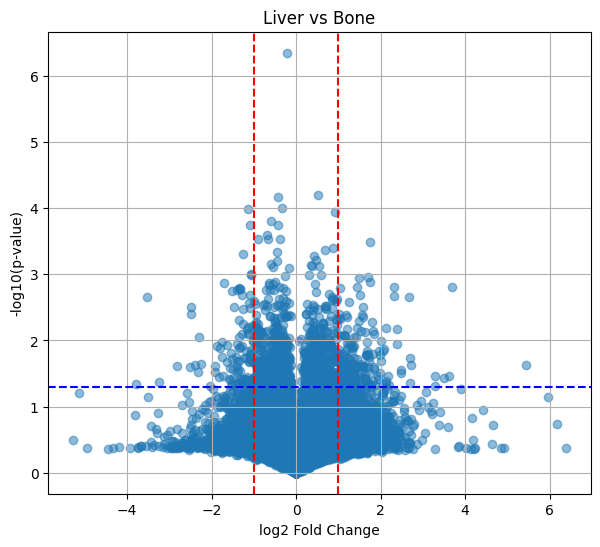

In [60]:
import matplotlib.pyplot as plt

def volcano_plot(df, title):
    plt.figure(figsize=(7,6))

    plt.scatter(df["log2FC"], -np.log10(df["pval"]), alpha=0.5)

    plt.axvline(x=1, color='red', linestyle='--')
    plt.axvline(x=-1, color='red', linestyle='--')
    plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--')

    plt.title(title)
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(p-value)")

    plt.grid()
    plt.show()

volcano_plot(liver_vs_lung, "Liver vs Lung")
volcano_plot(liver_vs_bone, "Liver vs Bone")

In [64]:
import gseapy as gp

# Upregulated in liver vs lung
up_liver_lung = sig_liver_lung_relaxed[sig_liver_lung_relaxed["log2FC"] > 0]["gene"].tolist()

# Downregulated
down_liver_lung = sig_liver_lung_relaxed[sig_liver_lung_relaxed["log2FC"] < 0]["gene"].tolist()

enr_up = gp.enrichr(
    gene_list=up_liver_lung,
    gene_sets="KEGG_2021_Human",
    organism="human",
    outdir=None
)

enr_up.results.head(10)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Linoleic acid metabolism,2/29,0.032925,0.970211,0,0,7.512251,25.643336,PLA2G4F;CYP1A2
1,KEGG_2021_Human,Tyrosine metabolism,2/36,0.048863,0.970211,0,0,5.963499,18.002164,FAHD1;DBH
2,KEGG_2021_Human,Caffeine metabolism,1/6,0.057670,0.970211,0,0,20.202041,57.636644,CYP1A2
3,KEGG_2021_Human,Riboflavin metabolism,1/8,0.076149,0.970211,0,0,14.428571,37.154519,RFK
4,KEGG_2021_Human,Ribosome biogenesis in eukaryotes,3/108,0.090994,0.970211,0,0,2.901031,6.953659,POP4;NOP10;GNL3
5,KEGG_2021_Human,Taurine and hypotaurine metabolism,1/11,0.103193,0.970211,0,0,10.098469,22.935221,GAD1
6,KEGG_2021_Human,Steroid hormone biosynthesis,2/61,0.121318,0.970211,0,0,3.432247,7.239789,CYP1A2;HSD17B12
7,KEGG_2021_Human,Thiamine metabolism,1/15,0.138030,0.970211,0,0,7.211735,14.281307,THTPA
8,KEGG_2021_Human,Central carbon metabolism in cancer,2/70,0.151430,0.970211,0,0,2.976621,5.618758,LDHA;FGFR1
9,KEGG_2021_Human,Protein export,1/23,0.203715,0.970211,0,0,4.587430,7.298747,SEC61A2
